# 04 — Annotation Quality

Annotation quality assessment, bounding box analysis, and composite dataset quality score.

**Analyzers:** `BBoxAnalyzer`, `QualityScorer`  
**Outputs:** `annotation_quality_report.md`, `summary.json`, `bbox_statistics.csv`, `quality_distribution.csv`, `quality_score.csv`

## Setup

In [1]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_NAME = "04_annotation_quality"
START_TIME = time.time()

from eda.utils.config import load_config
from eda.utils.logger import EDALogger
from eda.utils.metadata_loader import MetadataLoader
from eda.utils.wandb_manager import WandbManager
from eda.utils.plotting import PlotEngine, CATEGORICAL_COLOURS, DATASET_COLOURS, PALETTE
from eda.utils.report_generator import ReportGenerator
from eda.utils.system_monitor import SystemMonitor
from eda.utils.output_manager import OutputManager
from eda.utils.statistics import (
    BBoxAnalyzer, OverviewAnalyzer, ClassAnalyzer, QualityScorer,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config = load_config()
logger = EDALogger.setup(config, NOTEBOOK_NAME)
monitor = SystemMonitor()
plot_engine = PlotEngine(dpi=config.figure_dpi, formats=config.figure_formats)
output = OutputManager(config, NOTEBOOK_NAME)
snap_start = monitor.snapshot("start")
logger.log_start()

[22:14:30] INFO     ═══ EDA START: 04_annotation_quality ═══ | EDA v1.0.0 | Python 3.13.2 | Windows


In [2]:
loader = MetadataLoader(config)
df = loader.load()
metadata_hash = loader.metadata_hash
git_commit = EDALogger.get_git_commit()

wb = WandbManager(config, NOTEBOOK_NAME)
wb.init(metadata_hash=metadata_hash, git_commit=git_commit)
wb.log_system_info(snap_start)
logger.log_data_loaded(df.shape[0], df.shape[1], metadata_hash)

Preprocessing: Completely empty columns: ['duplicate_group_id']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.


wandb: Currently logged in as: saksham4data (saksham4data-vinkura) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: setting up run fq3ryqwn


...

wandb: Run data is saved locally in E:\Rads\eda\notebooks\wandb\run-20260801_221433-fq3ryqwn
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run eda-04_annotation_quality


wandb:  View project at https://wandb.ai/saksham4data-vinkura/RADS


wandb:  View run at https://wandb.ai/saksham4data-vinkura/RADS/runs/fq3ryqwn


[22:14:36] INFO     Data loaded: 5338 rows × 51 columns | hash=sha256:a761cf722...


## Annotation Quality Analysis

In [3]:
# Quality column distribution
if "quality" in df.columns:
    q_dist = df["quality"].value_counts(dropna=False)
    print("── Quality Rating Distribution ──")
    for val, cnt in q_dist.items():
        pct = cnt / len(df) * 100
        print(f"  {val}: {cnt:,} ({pct:.1f}%)")
else:
    print("quality column not found")

# Annotation availability
if "annotation_available" in df.columns:
    ann_dist = df["annotation_available"].value_counts(dropna=False)
    print("\n── Annotation Availability ──")
    for val, cnt in ann_dist.items():
        print(f"  {val}: {cnt:,}")

── Quality Rating Distribution ──
  nan: 3,311 (62.0%)
  Poor: 767 (14.4%)
  Fine: 558 (10.5%)
  Good: 327 (6.1%)
  Very_Poor: 308 (5.8%)
  Excellent: 67 (1.3%)

── Annotation Availability ──
  False: 4,238
  nan: 1,100


## Bounding Box Analysis

In [4]:
bbox_analyzer = BBoxAnalyzer(df, config)
bbox_results = bbox_analyzer.analyze()

if bbox_results.get("available"):
    print(f"Bounding boxes: {bbox_results['count']:,} records with bbox data")

    # Area stats
    area = bbox_results["area"]
    print(f"\n── Bbox Area ──")
    print(f"  Mean: {area['mean']:.6f}  |  Median: {area['median']:.6f}")
    print(f"  Zero-area: {area.get('zero_area_count', 0)}")

    # Aspect ratio
    ar = bbox_results["aspect_ratio"]
    if ar.get("count", 0) > 0:
        print(f"\n── Aspect Ratio ──")
        print(f"  Mean: {ar['mean']:.4f}  |  Median: {ar['median']:.4f}")

    # Validation
    val = bbox_results["validation"]
    print(f"\n── Bbox Validation ──")
    print(f"  Total: {val['total']:,}  |  Invalid: {val['total_invalid']:,} ({val['invalid_percent']:.1f}%)")
    if val["issues"]:
        for issue, count in val["issues"].items():
            print(f"  {issue}: {count:,}")

    # Edge proximity
    edge = bbox_results["edge_proximity"]
    print(f"\n── Edge Proximity (threshold={edge['threshold']}) ──")
    print(f"  Near any edge: {edge['near_any_edge']:,} ({edge['near_any_edge_percent']:.1f}%)")
else:
    print("Bounding box columns not available")

Bounding boxes: 4,238 records with bbox data

── Bbox Area ──
  Mean: 0.018871  |  Median: 0.009842
  Zero-area: 0

── Aspect Ratio ──
  Mean: 0.9825  |  Median: 0.9208

── Bbox Validation ──
  Total: 4,238  |  Invalid: 0 (0.0%)

── Edge Proximity (threshold=0.05) ──
  Near any edge: 386 (9.1%)


## Visualisation

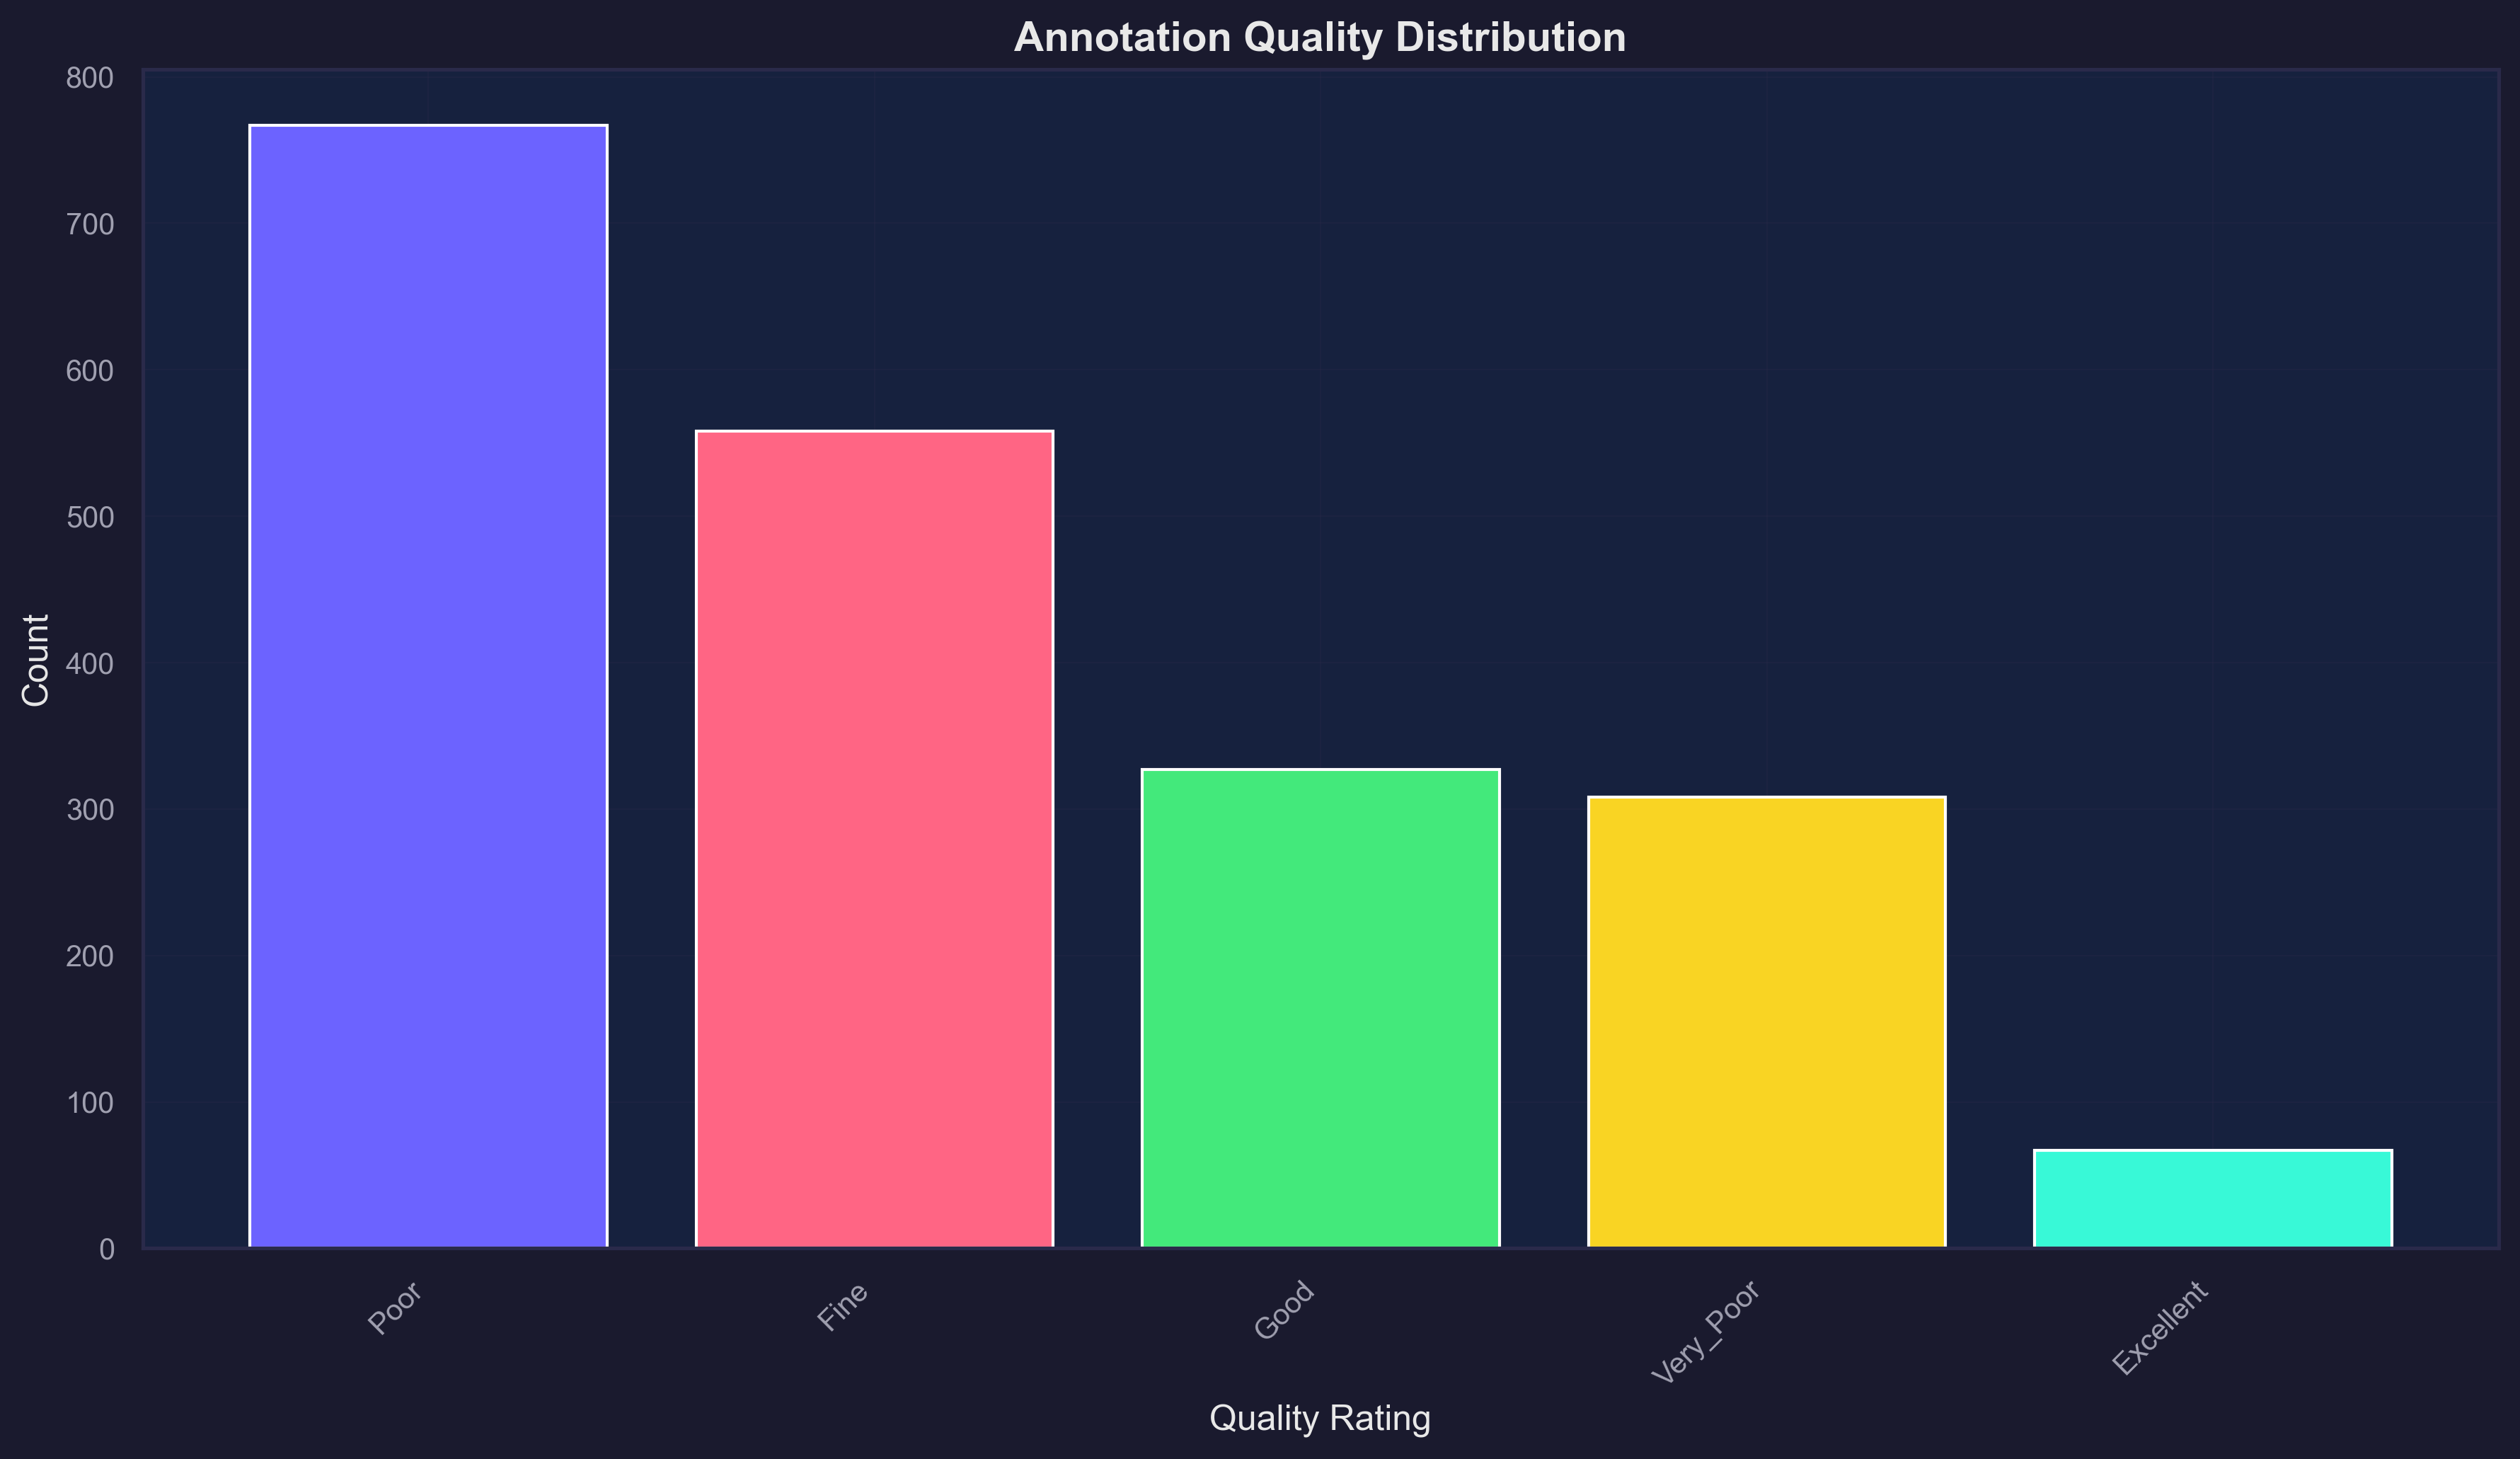

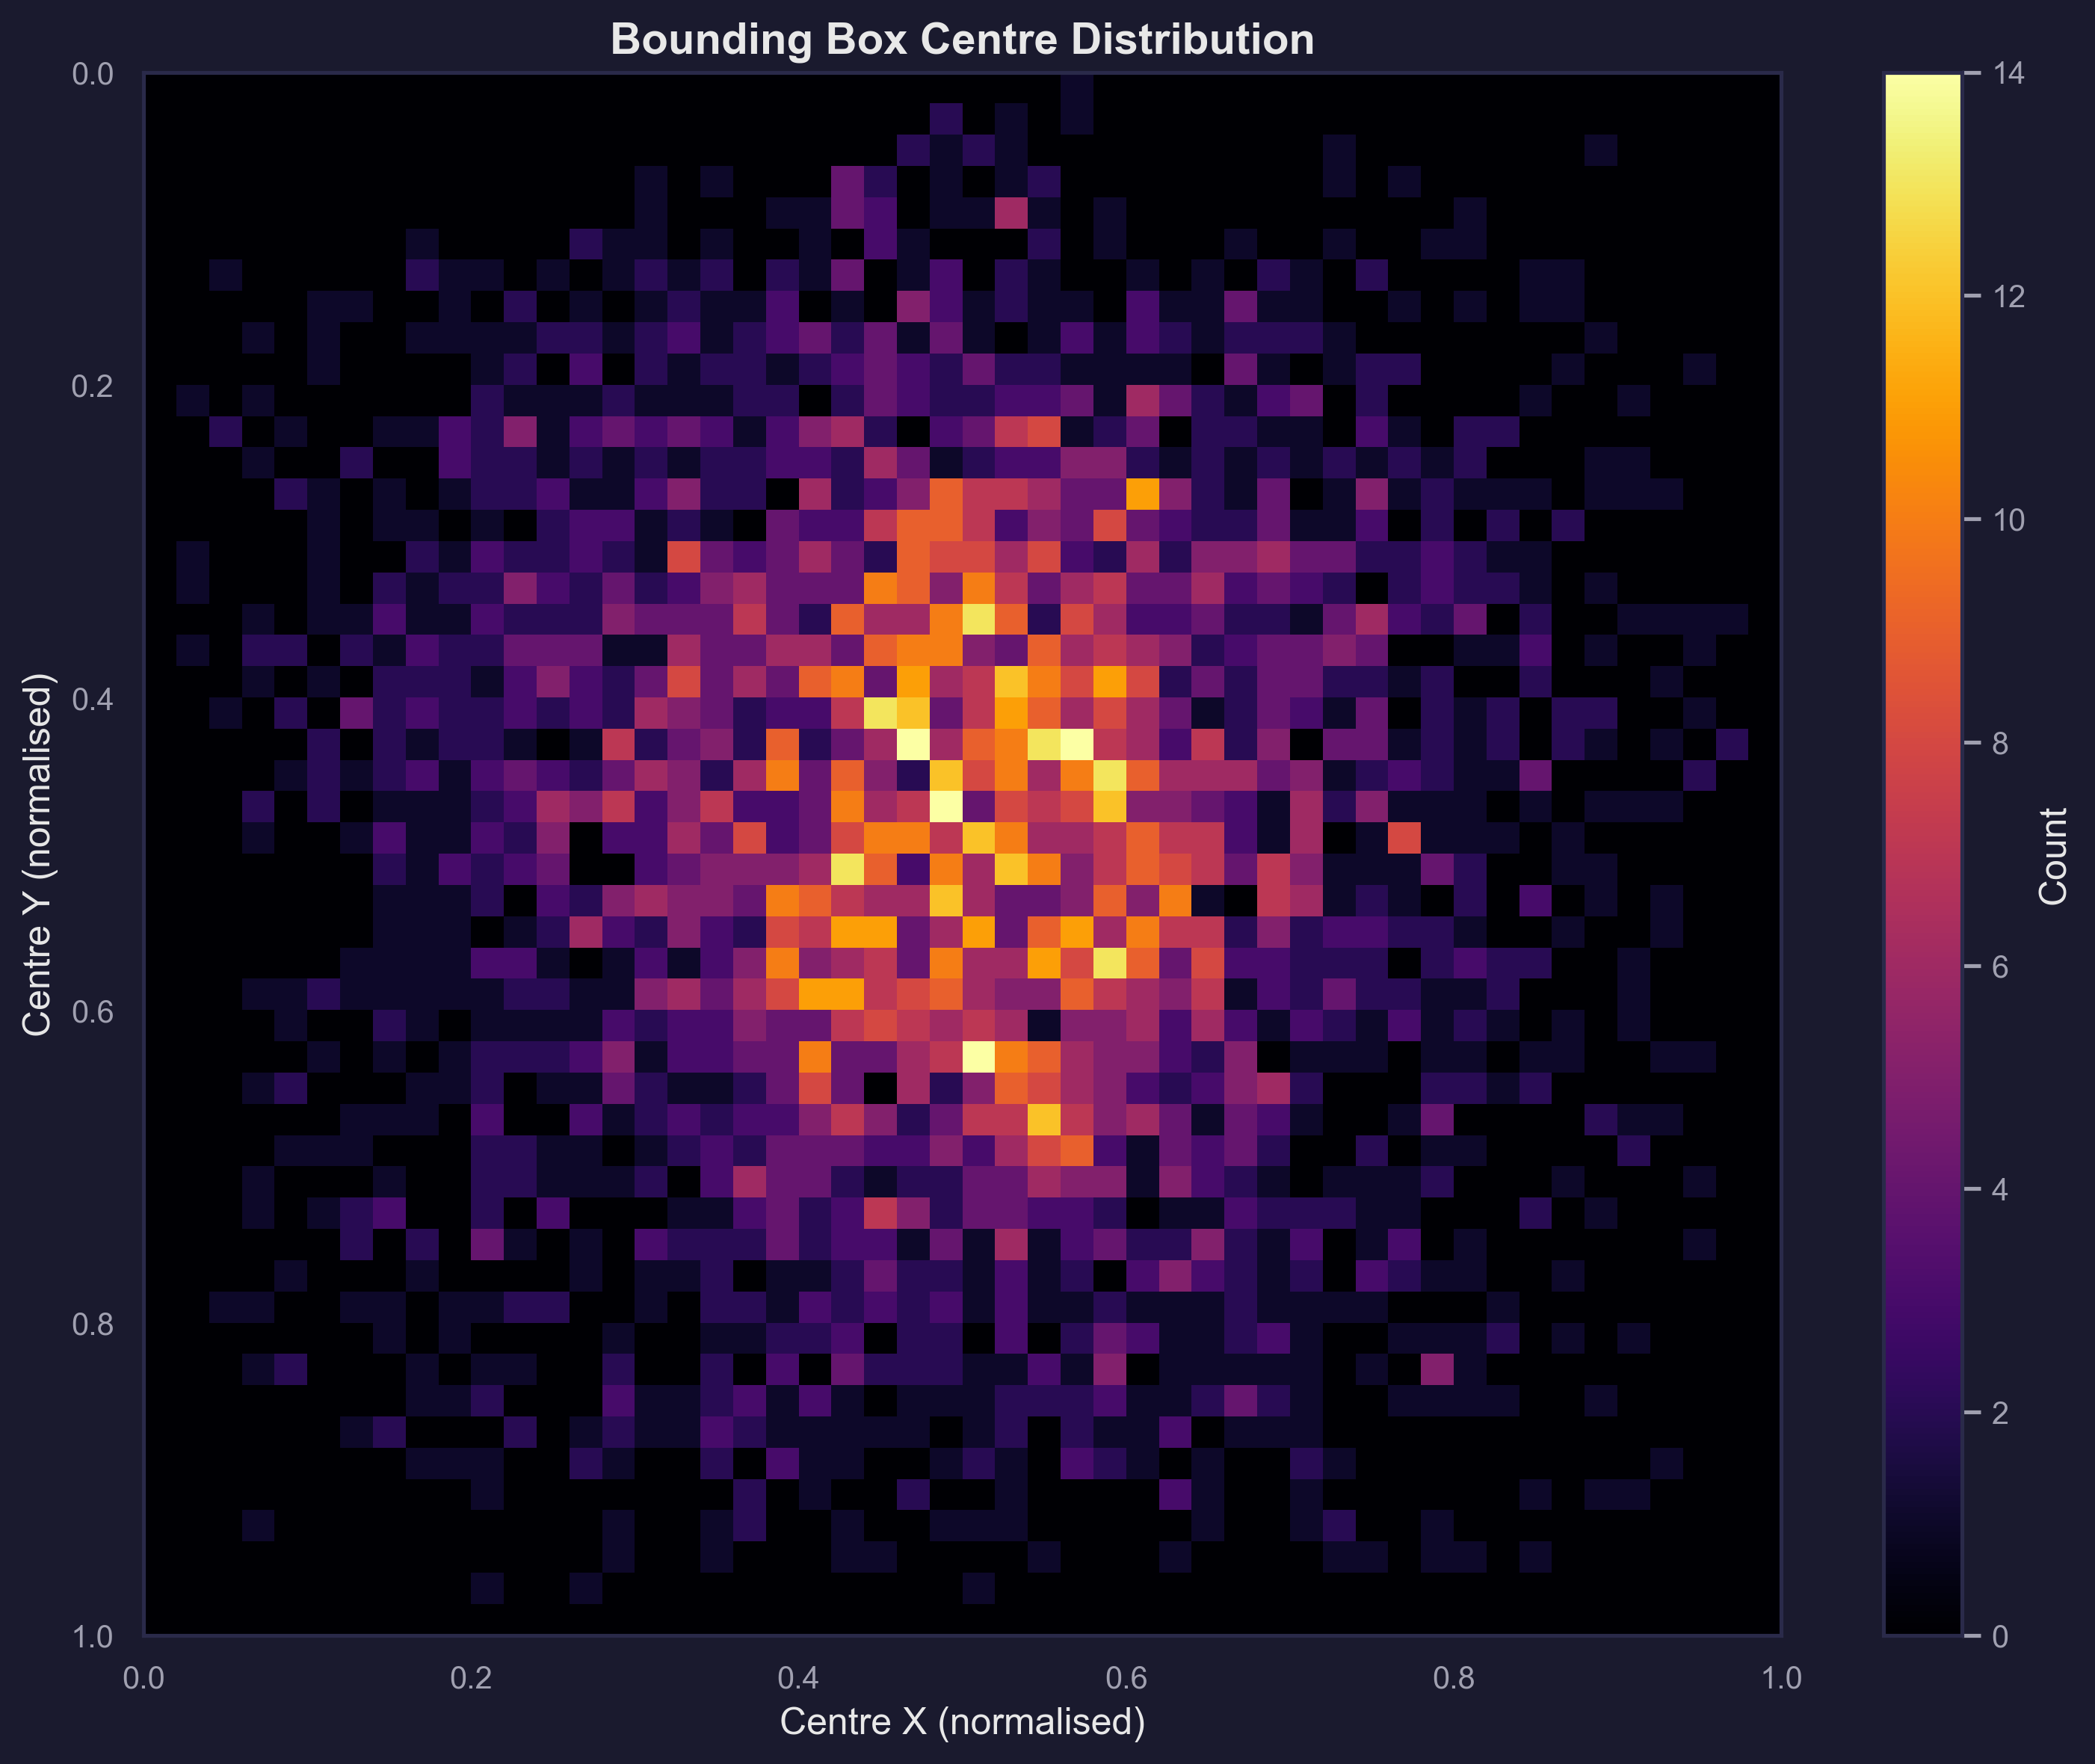

In [5]:
# Quality distribution bar chart
if "quality" in df.columns and df["quality"].notna().any():
    fig, ax = plot_engine.create_figure(figsize=(12, 7))
    plot_engine.plot_bar_chart(
        df["quality"].dropna(),
        title="Annotation Quality Distribution",
        xlabel="Quality Rating",
        ax=ax,
    )
    plt.tight_layout()
    output.save_figure(fig, "quality_distribution")
    wb.log_figure(fig, "quality_distribution")
    plt.show()

# Bbox centre heatmap
if bbox_results.get("available") and "center_x" in df.columns and "center_y" in df.columns:
    cx = df["center_x"].dropna()
    cy = df["center_y"].dropna()
    if len(cx) > 0:
        fig, ax = plot_engine.create_figure(figsize=(10, 8))
        plot_engine.plot_bbox_heatmap(
            cx, cy,
            title="Bounding Box Centre Distribution",
            ax=ax,
        )
        plt.tight_layout()
        output.save_figure(fig, "bbox_center_heatmap")
        wb.log_figure(fig, "bbox_center_heatmap")
        plt.show()

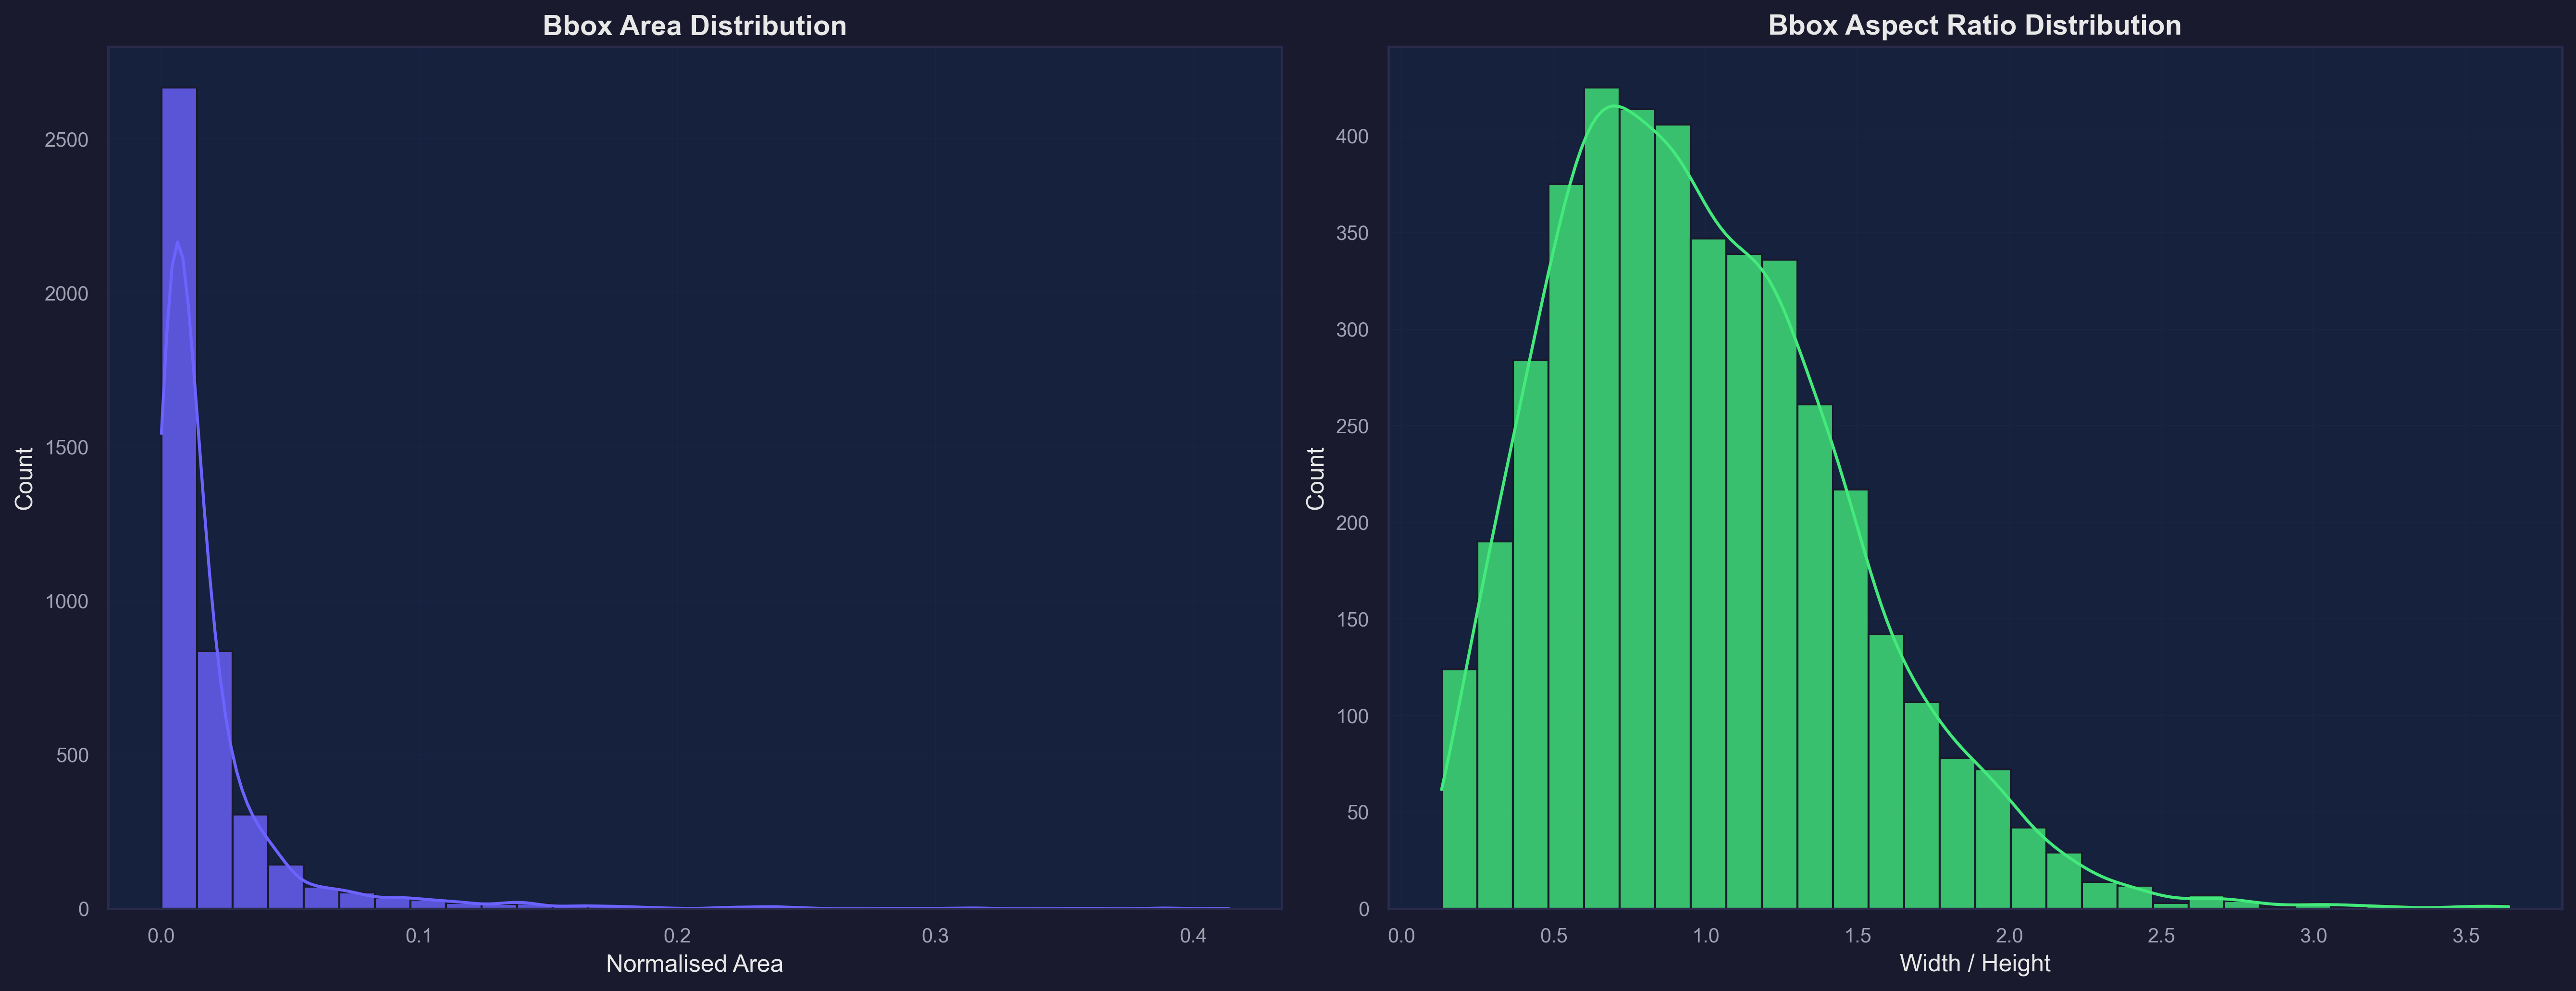

In [6]:
# Bbox area distribution
if bbox_results.get("available"):
    bbox_cols = config.bbox_columns
    bbox_df = df[bbox_cols].dropna(how="all").copy()
    if not bbox_df.empty:
        bbox_df["bw"] = (bbox_df["x2"] - bbox_df["x1"]).clip(lower=0)
        bbox_df["bh"] = (bbox_df["y2"] - bbox_df["y1"]).clip(lower=0)
        bbox_df["area"] = bbox_df["bw"] * bbox_df["bh"]

        fig, axes = plot_engine.create_figure(nrows=1, ncols=2, figsize=(18, 7))
        # Area histogram
        plot_engine.plot_distribution(
            bbox_df["area"],
            title="Bbox Area Distribution",
            xlabel="Normalised Area",
            ax=axes[0],
        )
        # Aspect ratio histogram
        valid_ar = bbox_df[bbox_df["bh"] > 0].copy()
        if not valid_ar.empty:
            valid_ar["ar"] = valid_ar["bw"] / valid_ar["bh"]
            plot_engine.plot_distribution(
                valid_ar["ar"],
                title="Bbox Aspect Ratio Distribution",
                xlabel="Width / Height",
                color=PALETTE["accent1"],
                ax=axes[1],
            )
        plt.tight_layout()
        output.save_figure(fig, "bbox_area_aspect_ratio")
        wb.log_figure(fig, "bbox_area_aspect_ratio")
        plt.show()

## Composite Dataset Quality Score

In [7]:
# Instantiate supporting analyzers for quality score components
overview_analyzer = OverviewAnalyzer(df, config)
overview_analyzer.analyze()

class_analyzer = ClassAnalyzer(df, config)
class_analyzer.analyze()

# Compute corruption score from validation/processing status
corruption_score = 1.0
if "validation_status" in df.columns:
    valid_count = (df["validation_status"].astype(str).str.lower() == "valid").sum()
    total = len(df)
    corruption_score = valid_count / total if total > 0 else 1.0

# Build quality scorer from analyzer instances
scorer = QualityScorer.from_analyzers(
    weights=config.quality_weights,
    overview_analyzer=overview_analyzer,
    class_analyzer=class_analyzer,
    bbox_analyzer=bbox_analyzer,
    corruption_score=corruption_score,
)
quality = scorer.compute()

print(f"\n{'='*50}")
print(f"  DATASET QUALITY SCORE: {quality['overall']:.1f} / 100  ({quality['grade']})")
print(f"{'='*50}")
print()
for comp_name, comp_info in quality["components"].items():
    print(f"  {comp_name:20s}: {comp_info['score']:5.1f}  (weight: {comp_info['weight']:.2f})")


  DATASET QUALITY SCORE: 86.7 / 100  (B+)

  missing_values      :  64.6  (weight: 0.20)
  duplicates          : 100.0  (weight: 0.15)
  class_imbalance     :  92.5  (weight: 0.25)
  invalid_bboxes      : 100.0  (weight: 0.20)
  corruption          :  78.1  (weight: 0.20)


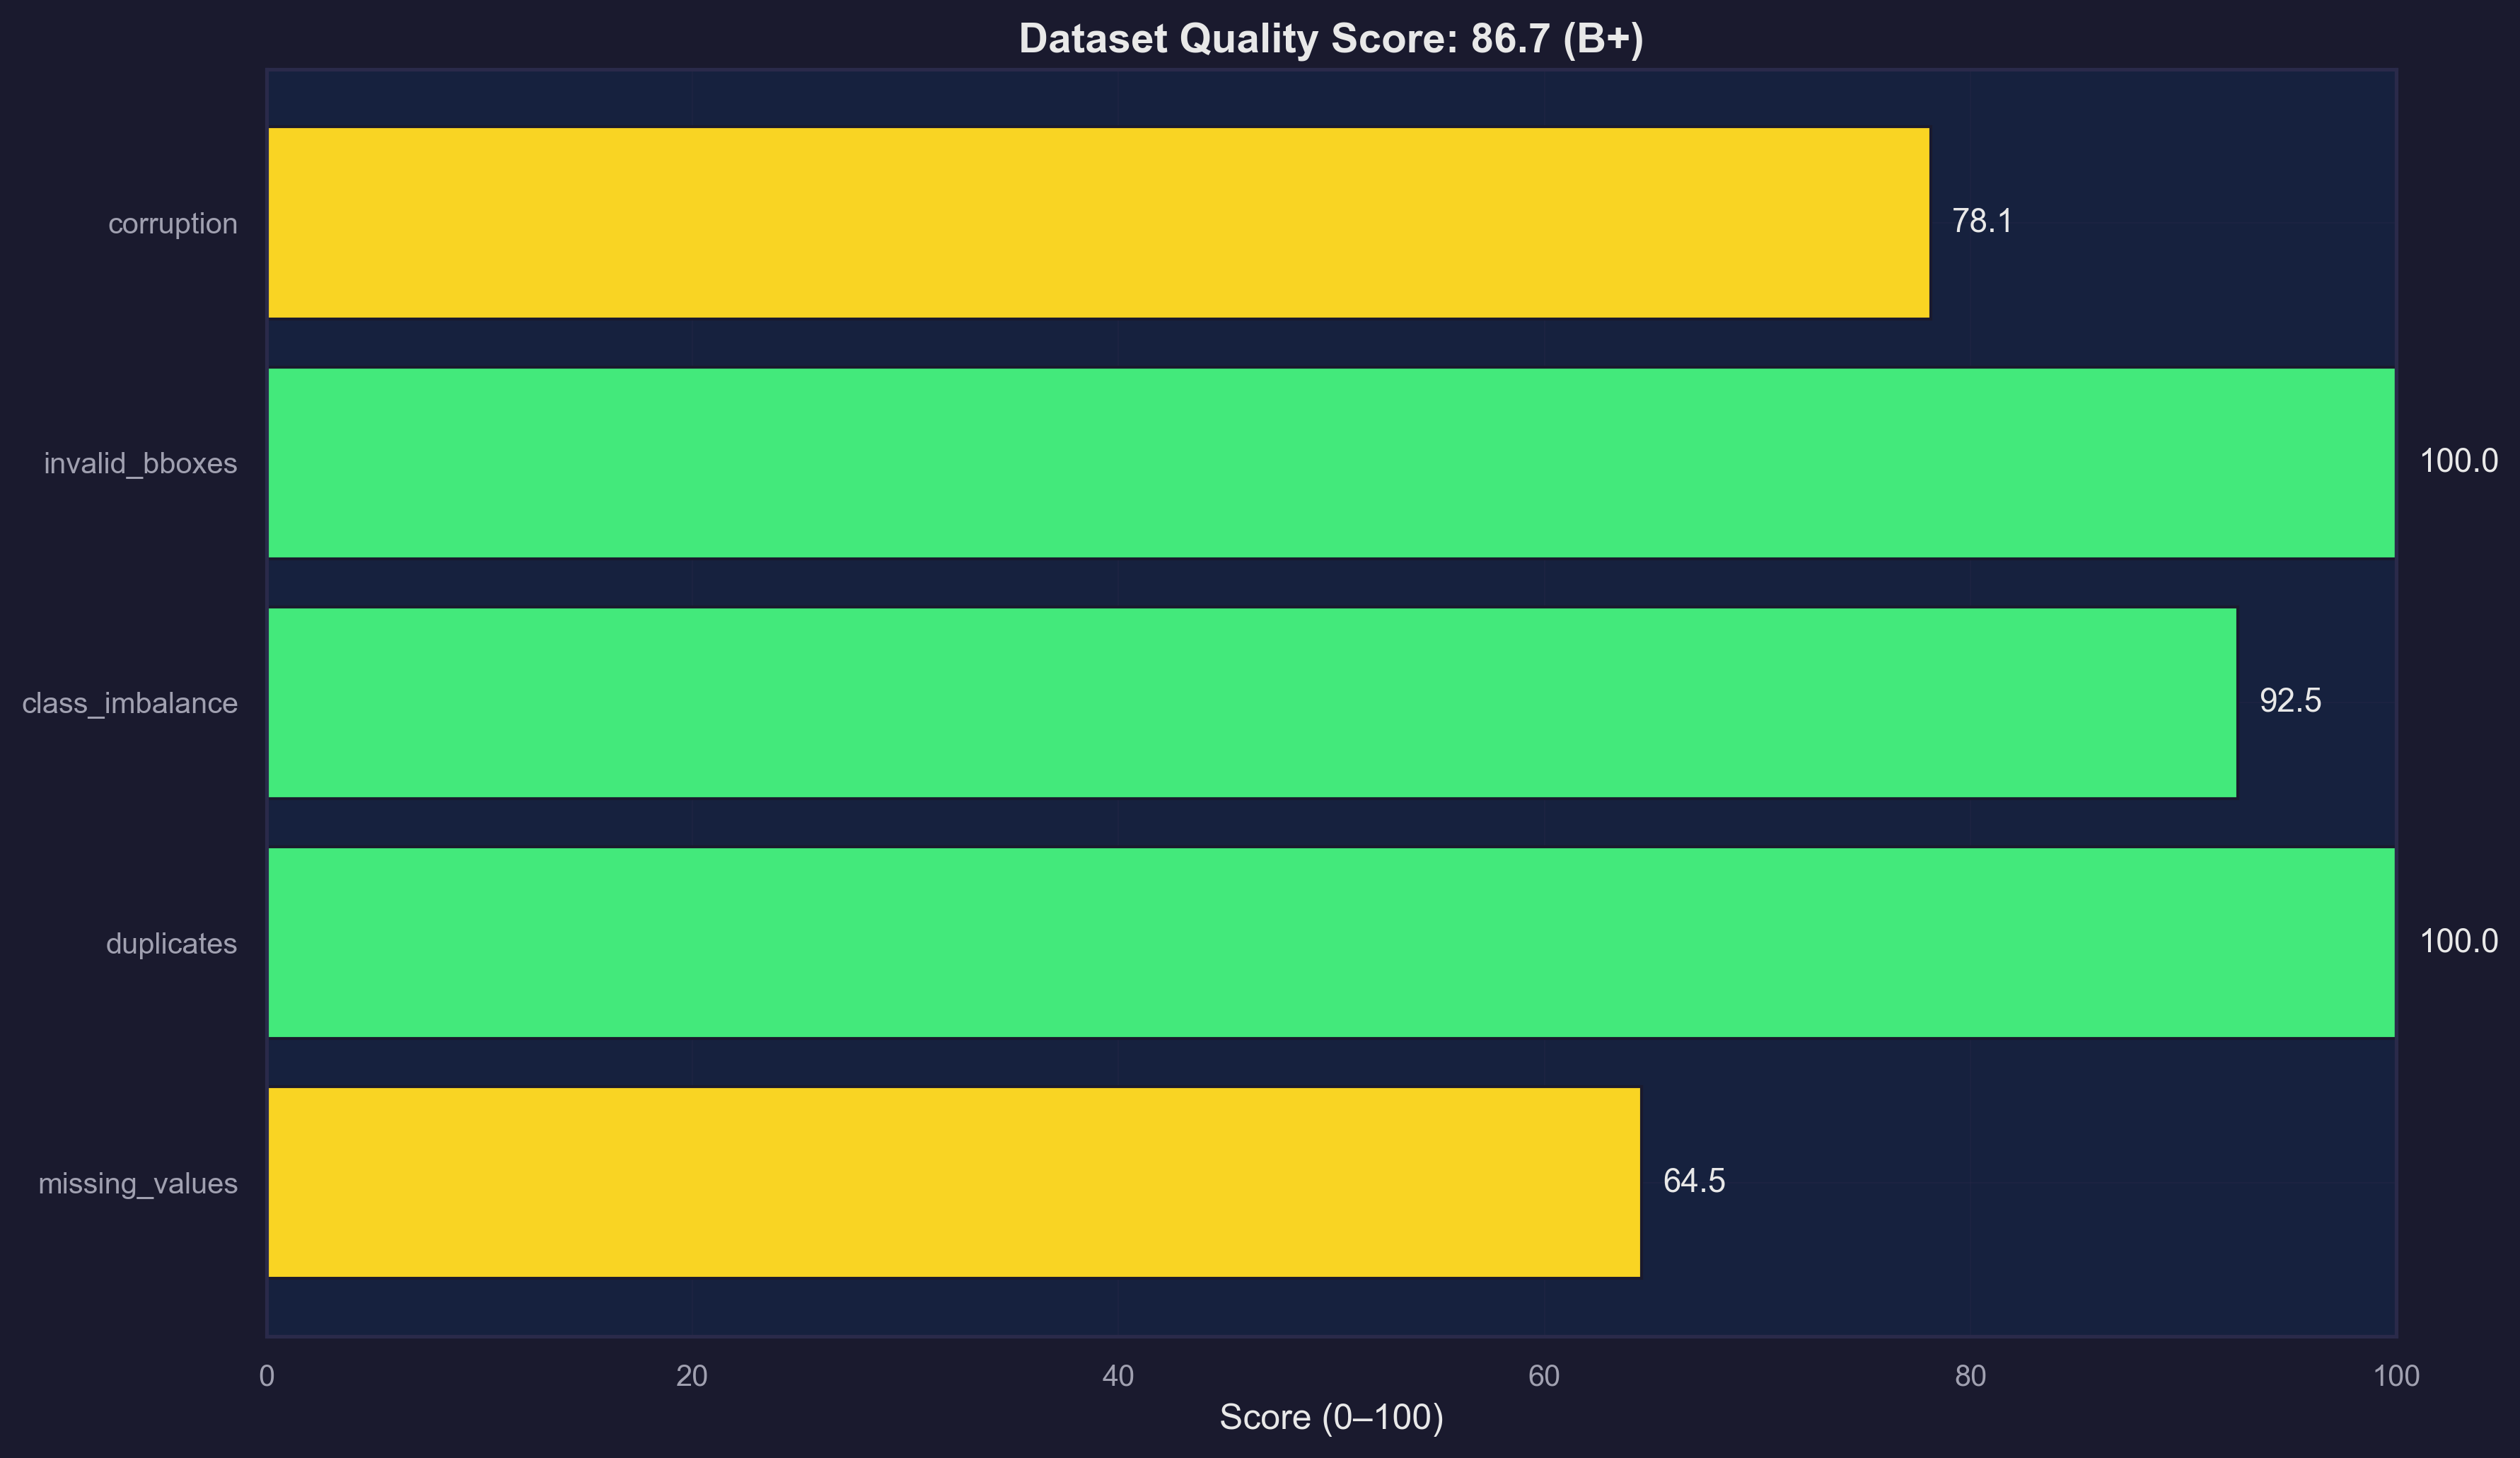

In [8]:
# Quality score breakdown visualisation
fig, ax = plot_engine.create_figure(figsize=(12, 7))
plot_engine.plot_quality_score_breakdown(
    {k: v["raw"] for k, v in quality["components"].items()},
    quality["overall"],
    quality["grade"],
    ax=ax,
)
plt.tight_layout()
output.save_figure(fig, "quality_score_breakdown")
wb.log_figure(fig, "quality_score_breakdown")
plt.show()

## Report & Export

In [9]:
rg = ReportGenerator(
    NOTEBOOK_NAME,
    eda_version=config.eda_version,
    dataset_version=loader.dataset_version,
    metadata_hash=metadata_hash,
    git_commit=git_commit,
    seed=config.seed,
)

# Annotation quality section
rg.add_heading("Annotation Quality")
if "quality" in df.columns:
    q_counts = df["quality"].value_counts(dropna=False)
    q_df = pd.DataFrame({"quality": q_counts.index.astype(str), "count": q_counts.values})
    rg.add_table(q_df, key="quality_distribution")
    output.save_csv(q_df, "quality_distribution")

# Bbox section
rg.add_heading("Bounding Box Analysis")
if bbox_results.get("available"):
    rg.add_key_value_list({
        "Total bbox records": bbox_results["count"],
        "Area mean": bbox_results["area"]["mean"],
        "Area median": bbox_results["area"]["median"],
        "Invalid bboxes": bbox_results["validation"]["total_invalid"],
        "Invalid percent": f"{bbox_results['validation']['invalid_percent']}%",
    })
    # Bbox stats CSV
    bbox_stats_rows = [
        {"metric": "area", **bbox_results["area"]},
        {"metric": "aspect_ratio", **bbox_results["aspect_ratio"]},
    ]
    output.save_csv(pd.DataFrame(bbox_stats_rows), "bbox_statistics")

# Quality score section
rg.add_heading("Composite Dataset Quality Score")
rg.add_key_value_list({
    "Overall Score": quality["overall"],
    "Grade": quality["grade"],
})
score_rows = [
    {"component": k, "score": v["score"], "weight": v["weight"]}
    for k, v in quality["components"].items()
]
score_df = pd.DataFrame(score_rows)
rg.add_table(score_df, key="quality_score_components")
output.save_csv(score_df, "quality_score")

rg.add_stats({
    "quality_overall": quality["overall"],
    "quality_grade": quality["grade"],
    "bbox_count": bbox_results.get("count", 0),
    "bbox_invalid_count": bbox_results.get("validation", {}).get("total_invalid", 0),
    "bbox_invalid_percent": bbox_results.get("validation", {}).get("invalid_percent", 0),
})

output.save_report(rg.build_markdown(), "annotation_quality_report")
output.save_summary_json(rg.build_summary_json(), "summary")

wb.log_stats({
    "quality/overall_score": quality["overall"],
    "quality/grade": quality["grade"],
    "bbox/total": bbox_results.get("count", 0),
    "bbox/invalid_count": bbox_results.get("validation", {}).get("total_invalid", 0),
    "bbox/invalid_percent": bbox_results.get("validation", {}).get("invalid_percent", 0),
})
wb.log_table(score_df, "quality_score_breakdown")

print("Reports and exports saved.")

Reports and exports saved.


## Teardown

In [10]:
snap_end = monitor.snapshot("end")
duration = time.time() - START_TIME

wb.log_system_info(snap_end)
wb.log_stats({"execution/duration_seconds": round(duration, 2)})
wb.log_notebook_outputs(
    output.figures_dir, output.reports_dir, output.exports_dir,
    metadata={"notebook": NOTEBOOK_NAME, "duration": round(duration, 2)},
)

output.finalize(
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
    git_commit=git_commit, metadata_hash=metadata_hash,
    rows_analyzed=df.shape[0], duration_seconds=duration,
)
logger.log_execution_summary(
    duration_seconds=duration, files_exported=output.all_exported_files,
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
)
wb.finish()

print(f"\n✅ Notebook complete in {duration:.1f}s")
print(f"   Exported {len(output.all_exported_files)} files")

wandb: Adding directory to artifact (E:\Rads\eda\figures\2026-08-01_16-44)... 

Done. 0.1s


wandb: Adding directory to artifact (E:\Rads\eda\reports\2026-08-01_16-44)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\exports\2026-08-01_16-44)... 

...

wandb: uploading data


wandb: 
wandb: Run history:
wandb:         bbox/invalid_count ▁
wandb:       bbox/invalid_percent ▁
wandb:                 bbox/total ▁
wandb: execution/duration_seconds ▁
wandb:      quality/overall_score ▁
wandb:           system/cpu/cores ▁▁
wandb:         system/cpu/percent █▁
wandb:        system/disk/percent ▁▁
wandb:        system/disk/used_gb ▁▁
wandb:      system/memory/percent ▁█
wandb:                         +2 ...
wandb: 
wandb: Run summary:
wandb:         bbox/invalid_count 0
wandb:       bbox/invalid_percent 0
wandb:                 bbox/total 4238
wandb: execution/duration_seconds 20.78
wandb:              quality/grade B+
wandb:      quality/overall_score 86.7
wandb:           system/cpu/cores 4
wandb:         system/cpu/percent 26
wandb:        system/disk/percent 68.7
wandb:        system/disk/used_gb 152
wandb:                         +3 ...
wandb: 


wandb:  View run eda-04_annotation_quality at: https://wandb.ai/saksham4data-vinkura/RADS/runs/fq3ryqwn
wandb:  View project at: https://wandb.ai/saksham4data-vinkura/RADS
wandb: Synced 5 W&B file(s), 5 media file(s), 14 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260801_221433-fq3ryqwn\logs



✅ Notebook complete in 20.8s
   Exported 13 files
